In [31]:
import sys
print(sys.executable)

c:\Users\joaco\Documents\ValueIQ\.venv\Scripts\python.exe


In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Makes plots look nicer
sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', None)



In [33]:
df = pd.read_csv('../data/raw/AmesHousing.csv')

print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (2930, 82)

First 5 rows:


,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,Neighborhood,Condition 1,Condition 2,Bldg Type,House Style,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Roof Style,Roof Matl,Exterior 1st,Exterior 2nd,Mas Vnr Type,Mas Vnr Area,Exter Qual,Exter Cond,Foundation,Bsmt Qual,Bsmt Cond,Bsmt Exposure,BsmtFin Type 1,BsmtFin SF 1,BsmtFin Type 2,BsmtFin SF 2,Bsmt Unf SF,Total Bsmt SF,Heating,Heating QC,Central Air,Electrical,1st Flr SF,2nd Flr SF,Low Qual Fin SF,Gr Liv Area,Bsmt Full Bath,Bsmt Half Bath,Full Bath,Half Bath,Bedroom AbvGr,Kitchen AbvGr,Kitchen Qual,TotRms AbvGrd,Functional,Fireplaces,Fireplace Qu,Garage Type,Garage Yr Blt,Garage Finish,Garage Cars,Garage Area,Garage Qual,Garage Cond,Paved Drive,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,5,1960,1960,Hip,CompShg,BrkFace,Plywood,Stone,112.0,TA,TA,CBlock,TA,Gd,Gd,BLQ,639.0,Unf,0.0,441.0,1080.0,GasA,Fa,Y,SBrkr,1656,0,0,1656,1.0,0.0,1,0,3,1,TA,7,Typ,2,Gd,Attchd,1960.0,Fin,2.0,528.0,TA,TA,P,210,62,0,0,0,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,Norm,1Fam,1Story,5,6,1961,1961,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,CBlock,TA,TA,No,Rec,468.0,LwQ,144.0,270.0,882.0,GasA,TA,Y,SBrkr,896,0,0,896,0.0,0.0,1,0,2,1,TA,5,Typ,0,NaN,Attchd,1961.0,Unf,1.0,730.0,TA,TA,Y,140,0,0,0,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,6,1958,1958,Hip,CompShg,Wd Sdng,Wd Sdng,BrkFace,108.0,TA,TA,CBlock,TA,TA,No,ALQ,923.0,Unf,0.0,406.0,1329.0,GasA,TA,Y,SBrkr,1329,0,0,1329,0.0,0.0,1,1,3,1,Gd,6,Typ,0,NaN,Attchd,1958.0,Unf,1.0,312.0,TA,TA,Y,393,36,0,0,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,7,5,1968,1968,Hip,CompShg,BrkFace,BrkFace,NaN,0.0,Gd,TA,CBlock,TA,TA,No,ALQ,1065.0,Unf,0.0,1045.0,2110.0,GasA,Ex,Y,SBrkr,2110,0,0,2110,1.0,0.0,2,1,3,1,Ex,8,Typ,2,TA,Attchd,1968.0,Fin,2.0,522.0,TA,TA,Y,0,0,0,0,0,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,5,5,1997,1998,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,PConc,Gd,TA,No,GLQ,791.0,Unf,0.0,137.0,928.0,GasA,Gd,Y,SBrkr,928,701,0,1629,0.0,0.0,2,1,3,1,TA,6,Typ,1,TA,Attchd,1997.0,Fin,2.0,482.0,TA,TA,Y,212,34,0,0,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [34]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).sort_values('Missing %', ascending=False)

print(missing_df[missing_df['Missing Count'] > 0])

                Missing Count  Missing %
Pool QC                  2917      99.56
Misc Feature             2824      96.38
Alley                    2732      93.24
Fence                    2358      80.48
Mas Vnr Type             1775      60.58
Fireplace Qu             1422      48.53
Lot Frontage              490      16.72
Garage Qual               159       5.43
Garage Yr Blt             159       5.43
Garage Cond               159       5.43
Garage Finish             159       5.43
Garage Type               157       5.36
Bsmt Exposure              83       2.83
BsmtFin Type 2             81       2.76
Bsmt Qual                  80       2.73
Bsmt Cond                  80       2.73
BsmtFin Type 1             80       2.73
Mas Vnr Area               23       0.78
Bsmt Full Bath              2       0.07
Bsmt Half Bath              2       0.07
Total Bsmt SF               1       0.03
BsmtFin SF 1                1       0.03
BsmtFin SF 2                1       0.03
Garage Area     

Drop
                Missing Count  Missing %
Pool QC                  2917      99.56
Misc Feature             2824      96.38
Alley                    2732      93.24
Fence                    2358      80.48

Fill with None
Mas Vnr Type             1775      60.58
Fireplace Qu             1422      48.53
Garage Qual               159       5.43
Garage Cond               159       5.43
Garage Finish             159       5.43
Garage Type               157       5.36
Bsmt Exposure              83       2.83
BsmtFin Type 2             81       2.76
Bsmt Qual                  80       2.73
Bsmt Cond                  80       2.73
BsmtFin Type 1             80       2.73

Fill with Year hose was built
Garage Yr Blt             159       5.43

Fill with Median
Lot Frontage              490      16.72
Mas Vnr Area               23       0.78
Bsmt Full Bath              2       0.07
Bsmt Half Bath              2       0.07
Total Bsmt SF               1       0.03
BsmtFin SF 1                1       0.03
BsmtFin SF 2                1       0.03
Garage Area                 1       0.03
Garage Cars                 1       0.03
Bsmt Unf SF                 1       0.03

Fill with Mode
Electrical                  1       0.03

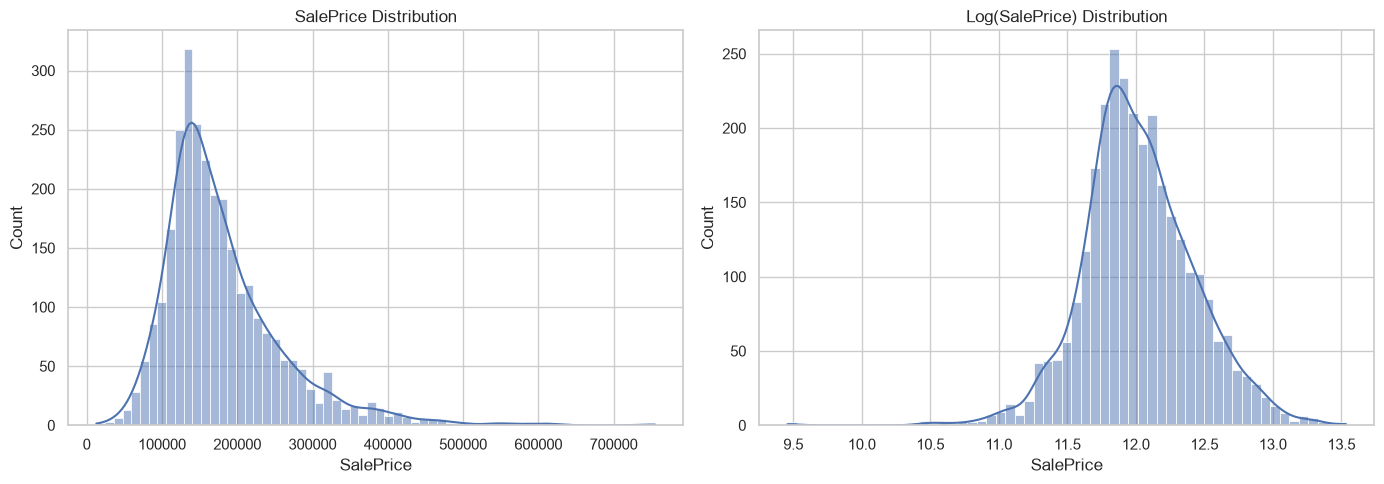

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['SalePrice'], kde=True, ax=axes[0])
axes[0].set_title('SalePrice Distribution')

sns.histplot(np.log1p(df['SalePrice']), kde=True, ax=axes[1])
axes[1].set_title('Log(SalePrice) Distribution')

plt.tight_layout()
plt.show()

## SalePrice Distribution

The raw SalePrice distribution is right-skewed — most houses cluster between 
$100k-$200k with a long tail extending to $700k+. This skew would cause linear 
models to underperform on expensive houses.

The log-transformed distribution is much closer to normal, though still slightly 
right-skewed. We will train our model on log(SalePrice) and convert predictions 
back with exp() when reporting results.

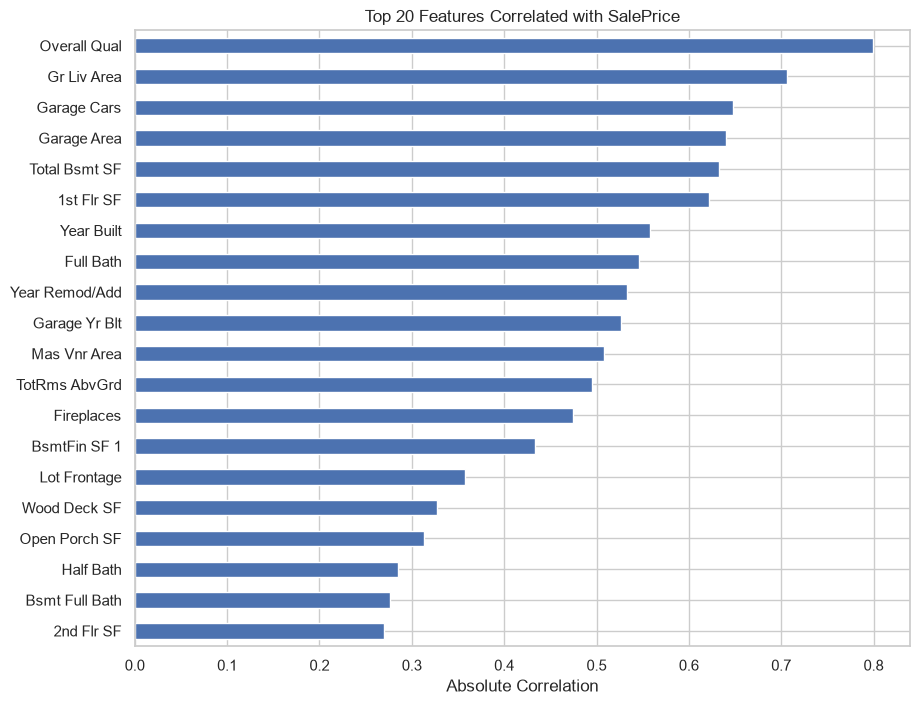

Overall Qual      0.799262
Gr Liv Area       0.706780
Garage Cars       0.647877
Garage Area       0.640401
Total Bsmt SF     0.632280
1st Flr SF        0.621676
Year Built        0.558426
Full Bath         0.545604
Year Remod/Add    0.532974
Garage Yr Blt     0.526965
Mas Vnr Area      0.508285
TotRms AbvGrd     0.495474
Fireplaces        0.474558
BsmtFin SF 1      0.432914
Lot Frontage      0.357318
Wood Deck SF      0.327143
Open Porch SF     0.312951
Half Bath         0.285056
Bsmt Full Bath    0.276050
2nd Flr SF        0.269373
Name: SalePrice, dtype: float64


In [36]:
corr = df.select_dtypes(include='number').corr()['SalePrice'].drop('SalePrice')
corr_sorted = corr.abs().sort_values(ascending=False)

plt.figure(figsize=(10, 8))
corr_sorted.head(20).plot(kind='barh')
plt.title('Top 20 Features Correlated with SalePrice')
plt.xlabel('Absolute Correlation')
plt.gca().invert_yaxis()
plt.show()

print(corr_sorted.head(20))

## Top Predictors of SalePrice

1. Overall Qual (0.80), overall material and finish quality. Strongest predictor by far.
2. Gr Liv Area (0.71), above-grade living area sq ft. Size matters most after quality.
3. Garage Cars (0.65), garage capacity. Likely a proxy for overall house size.
4. Garage Area (0.64), correlated with Garage Cars, likely redundant, watch for multicollinearity.
5. Total Bsmt SF (0.63), total basement square footage.

Note: Garage Cars and Garage Area are highly correlated with each other,
we may drop one during to avoid redundancy.

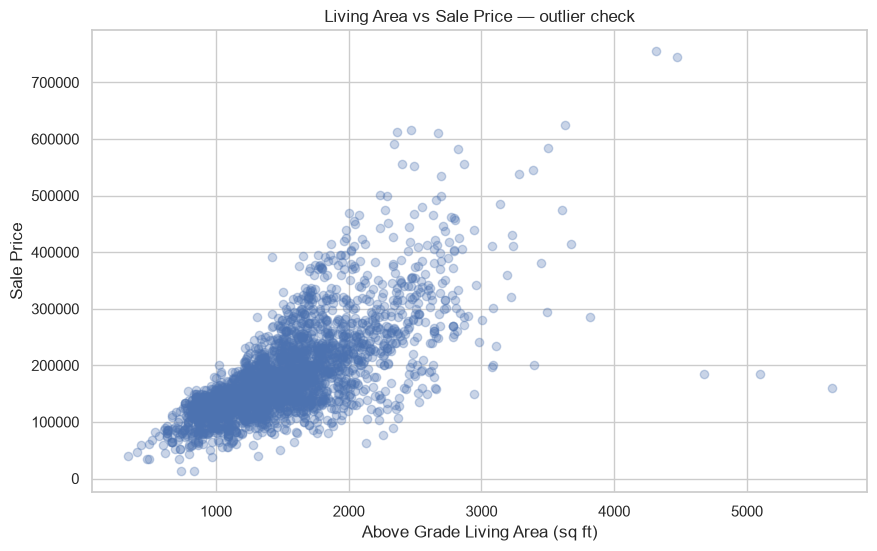

Suspicious outliers: 3 rows
      Gr Liv Area  SalePrice  Overall Qual
1498         5642     160000            10
2180         5095     183850            10
2181         4676     184750            10


In [37]:
plt.figure(figsize=(10, 6))
plt.scatter(df['Gr Liv Area'], df['SalePrice'], alpha=0.3)
plt.xlabel('Above Grade Living Area (sq ft)')
plt.ylabel('Sale Price')
plt.title('Living Area vs Sale Price — outlier check')
plt.show()

outliers = df[(df['Gr Liv Area'] > 4000) & (df['SalePrice'] < 200000)]
print(f"Suspicious outliers: {len(outliers)} rows")
print(outliers[['Gr Liv Area', 'SalePrice', 'Overall Qual']])

## Outlier Findings

Identified 3 suspicious rows where Gr Liv Area > 4000 but SalePrice < $200k:
- Row 1498: 5642 sqft, Overall Qual 10, sold for $160,000
- Row 2180: 5095 sqft, Overall Qual 10, sold for $183,850  
- Row 2181: 4676 sqft, Overall Qual 10, sold for $184,750

All three have maximum quality ratings (10/10) which makes the low prices 
even more anomalous, these are almost certainly non-arms-length transactions 
(estate sales, foreclosures, family transfers) where price doesn't reflect 
true market value. These rows will be removed during cleaning.